# DATS 2103 Final Project: Phishing Website Classification
Spring 2026

## 1. Introduction

### Problem Statement

Phishing websites are a persistent and costly cybersecurity threat: attackers create deceptive sites that mimic legitimate ones to steal credentials and financial information from users. Automated detection of phishing URLs at scale is essential to defending users at the browser, email, and network level. The goal of this project is to build a binary classifier that, given a set of structural and behavioral features extracted from a URL and its hosting infrastructure, predicts whether the website is phishing or legitimate.

### Dataset Summary

We use the Phishing Websites Dataset from the UCI Machine Learning Repository (Mohammad, Thabtah, & McCluskey, 2012). The dataset contains 11,055 URLs annotated with 30 categorical features that encode address-bar properties (e.g. presence of an IP address in place of a domain, URL length, use of `@` symbols), HTML/JavaScript behaviors (e.g. iframes, right-click disabling, popup windows), and domain/host attributes (e.g. SSL certificate state, age of domain, web traffic rank). Each feature is encoded as `-1` (phishing indicator), `0` (suspicious), or `1` (legitimate indicator), and the target variable `Result` takes values `-1` (phishing) or `1` (legitimate).

### Models Summary

We frame this as a supervised binary classification problem and compare three models drawn from the methods covered in DATS 2103:

1. Logistic Regression *(Chapter 4)* — a parametric linear model that gives interpretable coefficients with p-values and serves as our baseline. Required by the project rubric.
2. Random Forest *(Chapter 8)* — a bagged ensemble of decision trees that captures non-linear interactions and provides feature-importance scores that we can compare against the logistic regression coefficients.
3. Gradient Boosting *(Chapter 8)* — a sequentially-built ensemble that fits each new tree to the residuals of the previous trees, typically achieving the highest accuracy on tabular data and serving as a strong contrast to Random Forest's parallel approach.

This trio gives us a linear baseline, a parallel ensemble, and a sequential ensemble, three fundamentally different learning paradigms, for a meaningful comparison in the Results section. All models will be evaluated using 5-fold cross-validation on accuracy, AUROC, precision, recall, and F1.

## 2. Setup and Imports

We import the standard scientific Python stack along with the scikit-learn and statsmodels modules we'll need throughout the project. We set a fixed random seed of `42` so all train/test splits and stochastic models (Random Forest, Gradient Boosting) are reproducible.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 3. Data Loading

The dataset is provided as a CSV file. We load it, drop the non-informative `id` column (it's just a row index from 1 to 11055), and inspect the first few rows to confirm the structure.

In [2]:
df = pd.read_csv('Training_Dataset.csv')

df = df.drop(columns=['id'])

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns "
      f"(30 predictors + 1 target)")
df.head()

Dataset shape: 11055 rows × 31 columns (30 predictors + 1 target)


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,port,HTTPS_token,Request_URL,URL_of_Anchor,Links_in_tags,SFH,Submitting_to_email,Abnormal_URL,Redirect,on_mouseover,RightClick,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,1,-1,1,-1,1,-1,-1,-1,0,1,1,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,1,-1,1,0,-1,-1,1,1,0,1,1,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,1,-1,1,0,-1,-1,-1,-1,0,1,1,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,1,-1,-1,0,0,-1,1,1,0,1,1,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,1,1,1,0,0,-1,1,1,0,-1,1,-1,1,-1,-1,0,-1,1,1,1,1


## 4. Exploratory Data Analysis (EDA)

Before modeling, we explore the dataset to understand its structure, check for data quality issues, and identify which features carry the most predictive signal. This section answers four questions:

1. Are there missing values, duplicates, or unexpected data types?
2. Is the target balanced or imbalanced?
3. How are the feature values distributed?
4. Which features are most strongly associated with the target, and are there feature-pair correlations that could affect interpretation?

### 4.1 Data Quality Check

We confirm that all columns are integer-typed, that there are no missing values, and that there are no duplicate rows. This dataset has been pre-processed by the original authors so we expect it to be clean, but it is still essential to verify.

In [3]:
print("Data types:")
print(df.dtypes.value_counts())

n_missing = df.isnull().sum().sum()
print(f"\nTotal missing values: {n_missing}")

n_dup = df.duplicated().sum()
print(f"Total duplicate rows: {n_dup}  ({n_dup/len(df):.1%} of dataset)")
print(f"Unique rows: {df.drop_duplicates().shape[0]}")

unique_per_col = df.drop(columns=['Result']).apply(lambda s: tuple(sorted(s.unique())))
print(f"\nDistinct value-pattern groups across the 30 features:")
print(unique_per_col.value_counts())

Data types:
int64    31
Name: count, dtype: int64

Total missing values: 0
Total duplicate rows: 5206  (47.1% of dataset)
Unique rows: 5849

Distinct value-pattern groups across the 30 features:
(-1, 1)       21
(-1, 0, 1)     8
(0, 1)         1
Name: count, dtype: int64


We can see that every column is `int64` and there are no missing values. The features are encoded with one of two value sets: most are binary (`{-1, 1}`) while a subset are ternary (`{-1, 0, 1}`). One feature, `Redirect`, is the lone exception and uses `{0, 1}`. Because every feature is already on a comparable, bounded scale, no normalization or standardization is strictly required for tree-based models, and even logistic regression can be fit directly without scaling, since the integer {-1, 0, 1} encoding already places all features on a comparable, bounded range.

Duplicate rows are present, however, and suggest we take a closer look. With only 30 features each taking 2 or 3 values, the feature space has a finite number of possible patterns, and many distinct URLs map to the same feature signature. We investigate this in the next cell.

In [4]:
feature_cols = [c for c in df.columns if c != 'Result']

pattern_sizes = df.groupby(feature_cols).size()
n_unique_patterns = len(pattern_sizes)

label_agreement = df.groupby(feature_cols)['Result'].nunique()
consistent = (label_agreement == 1).sum()
conflicting = (label_agreement > 1).sum()

print(f"Unique feature patterns: {n_unique_patterns}")
print(f"  ...with consistent labels:  {consistent} ({consistent/n_unique_patterns:.1%})")
print(f"  ...with conflicting labels: {conflicting} ({conflicting/n_unique_patterns:.1%})")

print("\nDistribution of pattern multiplicity (top 10):")
print(pattern_sizes.value_counts().sort_index().head(10).to_string())

Unique feature patterns: 5785
  ...with consistent labels:  5721 (98.9%)
  ...with conflicting labels: 64 (1.1%)

Distribution of pattern multiplicity (top 10):
1     3171
2     1487
3      423
4      437
5       89
6       63
7       30
8       32
9       20
10      14


We can observe that there are 5,785 unique feature patterns across the 11,055 rows. The vast majority (5,721 patterns, ~99%) have consistent labels meaning every URL that shares the same feature vector is labeled the same way. Only 64 patterns have conflicting labels (a feature vector that appears as both phishing and legitimate in different rows). This represents irreducible noise: the 30 features cannot perfectly separate these cases, no matter what model we use. It places a soft upper bound on achievable accuracy at roughly 99% on this dataset.

We can keep all 11,055 rows. Duplicate rows are not data entry errors. They actually reflect the legitimate fact that many real world URLs map to the same feature fingerprint. Dropping them would discard real signal about prevalence and introduce its own bias. We will, however, note in our Limitations discussion that:
1. Random K-fold cross-validation may place duplicates of the same pattern in both train and test folds, producing a small optimistic bias on CV scores. This is the standard treatment in published work on this dataset.
2. The 64 conflicting label patterns set an irreducible error floor on any model trained on these features.

### 4.2 Target Distribution

The target `Result` is binary: `-1` indicates a phishing website and `1` indicates a legitimate website. We check the class balance, which directly affects which evaluation metrics are most meaningful.

Target distribution:
                count  proportion
Phishing (-1)    4898      0.4431
Legitimate (1)   6157      0.5569


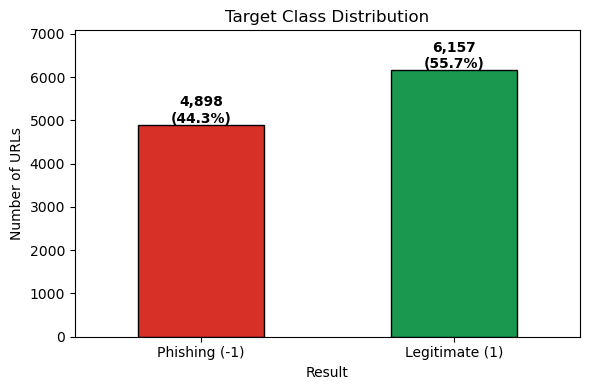

In [5]:
target_counts = df['Result'].value_counts().sort_index()
target_props = df['Result'].value_counts(normalize=True).sort_index()

print("Target distribution:")
target_summary = pd.DataFrame({
    'count': target_counts,
    'proportion': target_props.round(4)
})
target_summary.index = ['Phishing (-1)', 'Legitimate (1)']
print(target_summary)

fig, ax = subplots(figsize=(6, 4))
colors = ['#d73027', '#1a9850']
target_counts.plot(kind='bar', ax=ax, color=colors, edgecolor='black')
ax.set_xticklabels(['Phishing (-1)', 'Legitimate (1)'], rotation=0)
ax.set_ylabel('Number of URLs')
ax.set_title('Target Class Distribution')
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 50, f'{v:,}\n({target_props.iloc[i]:.1%})',
            ha='center', fontweight='bold')
ax.set_ylim(0, target_counts.max() * 1.15)
plt.tight_layout()
plt.show()

The dataset contains 6,157 legitimate URLs (55.7%) and 4,898 phishing URLs (44.3%). This is a mildly imbalanced but practically balanced distribution. This is close enough to 50/50 that we do not need to resort to resampling techniques (SMOTE, class weights), and accuracy will be a reasonably informative metric. We will still report precision, recall, F1, and AUROC alongside accuracy because in a security context the costs of false negatives (missing a phishing site) and false positives (blocking a legitimate site) are asymmetric.

### 4.3 Feature Value Distributions

To get a sense of how each feature is populated, we compute the proportion of `-1`, `0`, and `1` values across all 30 predictors. Features whose distribution is heavily skewed toward one value (e.g. 95%+ of observations on a single value) carry less information than features whose values are spread across the range.

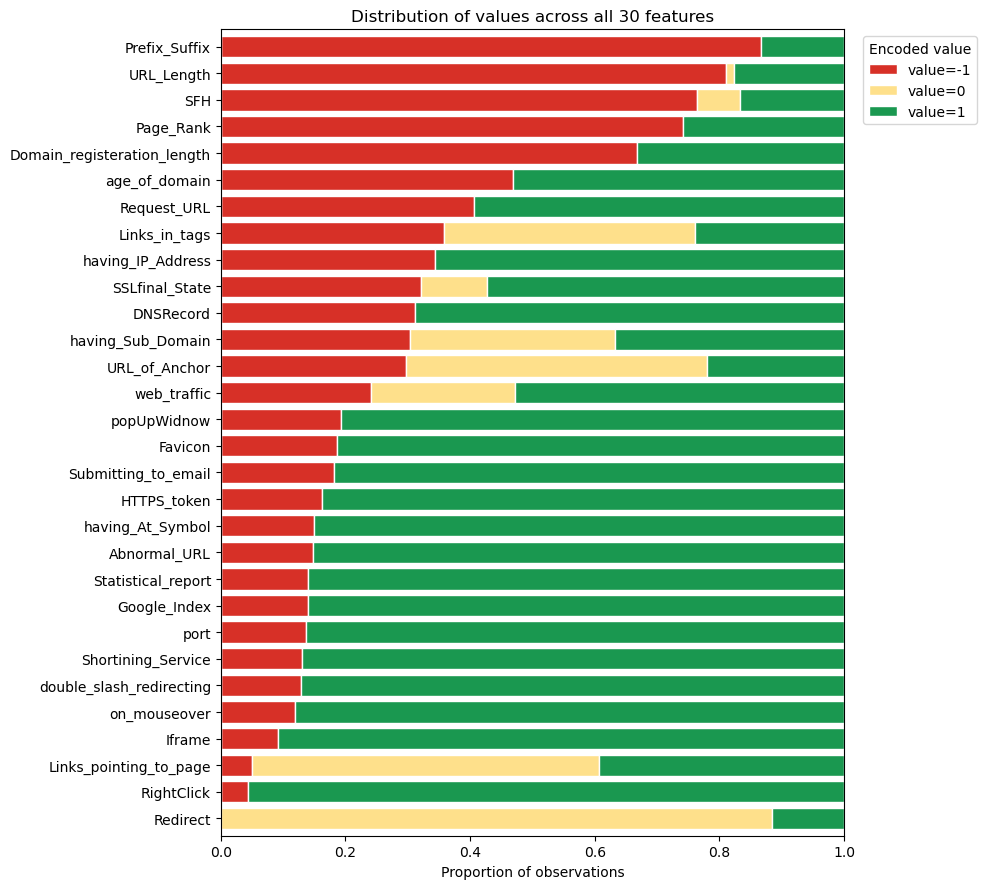

In [6]:
# Per-feature value distribution (proportions)
feature_cols = [c for c in df.columns if c != 'Result']
value_props = pd.DataFrame({
    c: df[c].value_counts(normalize=True) for c in feature_cols
}).T.fillna(0)

# Reorder columns to -1, 0, 1
value_props = value_props.reindex(columns=[-1, 0, 1], fill_value=0)
value_props.columns = ['value=-1', 'value=0', 'value=1']

# Sort features by proportion of phishing-indicator values for visualization
value_props_sorted = value_props.sort_values('value=-1', ascending=True)

fig, ax = subplots(figsize=(10, 9))
value_props_sorted.plot(
    kind='barh', stacked=True, ax=ax,
    color=['#d73027', '#fee08b', '#1a9850'], width=0.8, edgecolor='white'
)
ax.set_xlabel('Proportion of observations')
ax.set_title('Distribution of values across all 30 features')
ax.legend(title='Encoded value', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

Findings. Most features have a meaningful spread of values across `-1` and `1`, though several (e.g. `Iframe`, `RightClick`, `popUpWidnow`, `Submitting_to_email`) are heavily skewed. We can see that over 90% of observations take the same value, suggesting these features may carry little discriminative signal. The ternary features (those with non-zero `value=0` bars) include `URL_of_Anchor`, `Links_in_tags`, `SFH`, `having_Sub_Domain`, `URL_Length`, `web_traffic`, `Links_pointing_to_page`, and `SSLfinal_State`. These are the features for which the original authors defined a "Suspicious" middle category in addition to the binary "Phishing" and "Legitimate" extremes.

### 4.4 Feature–Target Correlation

Pearson correlation between each feature and the target gives us a quick first look at which features are most linearly predictive. Because all features are encoded with the same direction (higher value → more "legitimate"), a positive correlation here means the feature behaves as the original authors intended. Strong correlations (|r| > 0.3) suggest the feature is a strong individual signal; near-zero correlations suggest the feature has little univariate predictive power (though it could still be useful in interaction with others).

Top 10 features by |correlation| with Result:
SSLfinal_State                 0.715
URL_of_Anchor                  0.693
Prefix_Suffix                  0.349
web_traffic                    0.346
having_Sub_Domain              0.298
Request_URL                    0.253
Links_in_tags                  0.248
Domain_registeration_length   -0.226
SFH                            0.221
Google_Index                   0.129

Bottom 5 features (weakest signal):
Submitting_to_email    0.018
RightClick             0.013
Iframe                -0.003
Favicon               -0.000
popUpWidnow            0.000


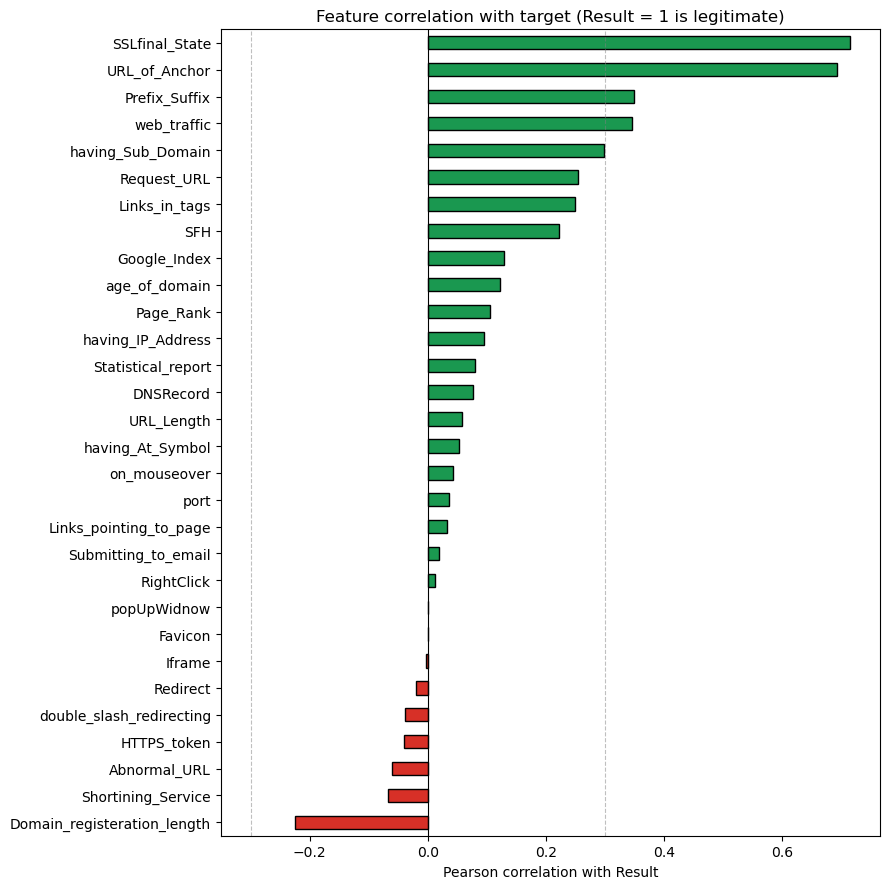

In [7]:
# Correlation of each feature with the target
target_corr = (df.corr()['Result']
                 .drop('Result')
                 .sort_values(key=abs, ascending=False))

print("Top 10 features by |correlation| with Result:")
print(target_corr.head(10).round(3).to_string())
print("\nBottom 5 features (weakest signal):")
print(target_corr.tail(5).round(3).to_string())

# Bar chart of all correlations
fig, ax = subplots(figsize=(9, 9))
ordered = target_corr.sort_values()
colors = ['#d73027' if v < 0 else '#1a9850' for v in ordered.values]
ordered.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(0.3, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(-0.3, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Pearson correlation with Result')
ax.set_title('Feature correlation with target (Result = 1 is legitimate)')
plt.tight_layout()
plt.show()

Findings. Two features dominate the linear signal:
- `SSLfinal_State` (r = 0.715) — whether the website uses HTTPS, who issued the certificate, and how old the certificate is. This is by far the strongest individual predictor.
- `URL_of_Anchor` (r = 0.693) — the percentage of `<a>` anchor tags pointing to a different domain than the page itself. Phishing pages tend to have many anchors pointing to the legitimate target site they're impersonating.

A second tier of moderately predictive features (|r| ≈ 0.2–0.35) includes `Prefix_Suffix` (dashes in domain name), `web_traffic` (Alexa traffic rank), `having_Sub_Domain`, `Request_URL`, `Links_in_tags`, `Domain_registeration_length`, and `SFH` (Server Form Handler).

A handful of features (`Favicon`, `popUpWidnow`, `Iframe`, `RightClick`, `Submitting_to_email`) have correlations very close to zero. These are good candidates to interpret in the discussion section: they were proposed by the original authors based on heuristic reasoning, but in practice they offer almost no univariate predictive value. Tree-based models may still extract value from them via interactions, but a logistic regression model is unlikely to assign them significant coefficients.

### 4.5 Feature–Feature Correlations (Multicollinearity Check)

For logistic regression, highly correlated predictors can inflate coefficient standard errors and make the resulting β estimates unreliable to interpret individually. For tree-based models this matters less, but it's still useful context. We compute the full feature-feature correlation matrix and flag pairs with |r| > 0.5.

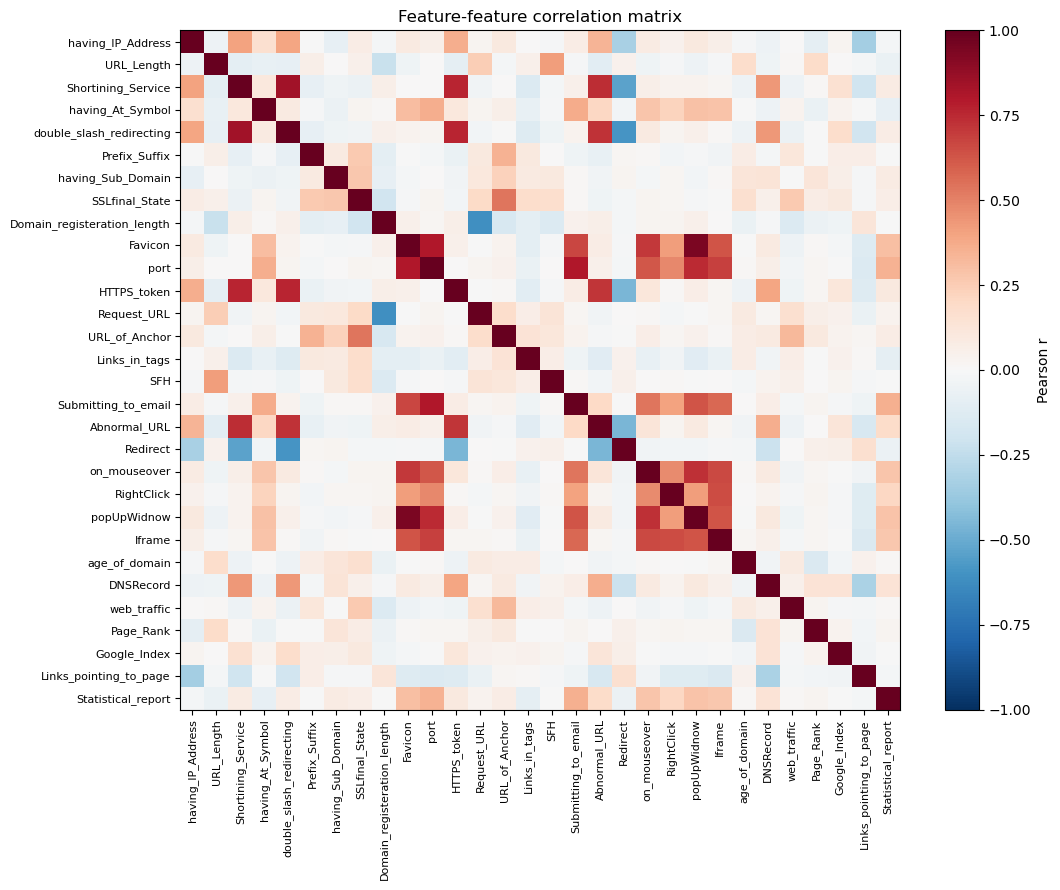

Feature pairs with |r| > 0.5: 26 pairs
                  feature_1                feature_2  correlation
                    Favicon              popUpWidnow        0.940
         Shortining_Service double_slash_redirecting        0.843
                    Favicon                     port        0.804
                       port      Submitting_to_email        0.799
   double_slash_redirecting              HTTPS_token        0.761
         Shortining_Service              HTTPS_token        0.758
                       port              popUpWidnow        0.749
         Shortining_Service             Abnormal_URL        0.739
               on_mouseover              popUpWidnow        0.734
   double_slash_redirecting             Abnormal_URL        0.724
                HTTPS_token             Abnormal_URL        0.716
                    Favicon             on_mouseover        0.706
                       port                   Iframe        0.687
                    Favicon      Subm

In [8]:
feat_corr = df.drop(columns=['Result']).corr()

# Heatmap
fig, ax = subplots(figsize=(11, 9))
im = ax.imshow(feat_corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(feat_corr.columns)))
ax.set_yticks(range(len(feat_corr.columns)))
ax.set_xticklabels(feat_corr.columns, rotation=90, fontsize=8)
ax.set_yticklabels(feat_corr.columns, fontsize=8)
ax.set_title('Feature-feature correlation matrix')
plt.colorbar(im, ax=ax, label='Pearson r')
plt.tight_layout()
plt.show()

# Identify highly correlated pairs
upper = feat_corr.where(
    np.triu(np.ones(feat_corr.shape), k=1).astype(bool)
)
high_pairs = (upper.stack()
                   .reset_index()
                   .rename(columns={'level_0': 'feature_1',
                                    'level_1': 'feature_2',
                                    0: 'correlation'}))
high_pairs = high_pairs[high_pairs['correlation'].abs() > 0.5]
high_pairs = high_pairs.reindex(
    high_pairs['correlation'].abs().sort_values(ascending=False).index
)
print(f"Feature pairs with |r| > 0.5: {len(high_pairs)} pairs")
print(high_pairs.round(3).to_string(index=False))

Findings. Several feature pairs show strong correlation:
- `popUpWidnow` ↔ `Favicon` (r = 0.94) — these two features almost always agree, likely because phishing kits that spawn popups also tend to use suspicious favicons.
- `double_slash_redirecting` ↔ `Shortining_Service` (r = 0.84) — URL shorteners and `//` redirects are both URL-obfuscation tactics that co-occur.
- `port` ↔ `Favicon` (r = 0.80), `Submitting_to_email` ↔ `port` (r = 0.80), `HTTPS_token` ↔ `double_slash_redirecting` (r = 0.76).

This multicollinearity is something we will explicitly discuss in the Results and Discussion section: when we report logistic regression coefficients and p-values, some of them may appear non-significant even though the underlying features are predictive, because the variance is being shared with a correlated partner. Tree-based models (Random Forest, Gradient Boosting) are robust to this, they'll simply pick whichever feature splits cleanest at each node, which is one reason we include them.

## 5. EDA Summary and Plan for Subsequent Sections

### Summary of EDA Findings

| Aspect | Finding |
|---|---|
| Size | 11,055 observations × 30 predictors + 1 target |
| Missingness | None (no nulls) |
| Encoding | All features integer-encoded as `-1` / `0` / `1` |
| Duplicate rows | 5,206 (47%) — kept; reflect the discrete feature space, not errors |
| Conflicting-label patterns | 64 of 5,785 (~1%) — sets a ~99% accuracy ceiling |
| Class balance | 55.7% legitimate / 44.3% phishing — mildly imbalanced |
| Strongest predictors | `SSLfinal_State` (r=0.71), `URL_of_Anchor` (r=0.69) |
| Weakest predictors | `Favicon`, `popUpWidnow`, `Iframe`, `RightClick`, `Submitting_to_email` (|r| < 0.05) |
| Multicollinearity | Several feature pairs with |r| > 0.7; matters for logistic regression interpretation |

### Plan for the Remainder of the Notebook

Based on the EDA, the next steps are:

1. Section 6 — Pre-processing. Recode the target from `{-1, 1}` to `{0, 1}` for compatibility with sklearn's `predict_proba` and AUROC scoring conventions. Split the data into a 80/20 stratified train/test split. Optionally standardize for the logistic regression model (does not affect the tree-based models).

2. Section 7 — Modeling. Fit three classifiers using 5-fold stratified cross-validation on the training set:
   - Logistic Regression (with `statsmodels.GLM` for inference + `sklearn.LogisticRegression` for prediction)
   - Random Forest Classifier
   - Gradient Boosting Classifier

   Report mean ± std cross-validation accuracy, AUROC, precision, recall, and F1.

3. Section 8 — Results and Discussion. Compare the three models quantitatively, plot ROC curves, examine feature importances (logistic β values vs. Random Forest importances vs. Gradient Boosting importances), and discuss model trade-offs and limitations.

4. Section 9 — Citations. Cite the dataset source, the ISLP textbook, and any external code references.

### Final dataset dimensions for the main analysis

After dropping the `id` column, our analysis uses:
- n = 11,055 observations
- p = 30 predictors
- target = `Result` (binary)

These numbers will not change between EDA and modeling — preprocessing in Section 6 only re-encodes and splits the data; it does not drop rows or columns.

## 6. Pre-processing

The EDA revealed that the data is already remarkably clean — no missing values, all features on a comparable integer-encoded scale, and a mildly imbalanced but workable class distribution. Pre-processing for this dataset therefore consists of two minimal steps:

1. Recode the target from `{-1, 1}` to `{0, 1}`, where `1 = phishing` and `0 = legitimate`. This makes phishing the *positive class*, which is conventional in security applications (we are detecting the threat) and is what scikit-learn's `predict_proba` and `roc_auc_score` expect.
2. Stratified train/test split at 80/20, preserving the class proportions in both subsets, with a fixed random state for reproducibility.

We deliberately do not drop the duplicate-row patterns identified in the EDA: they are a real property of the feature space, not data-entry errors, and dropping them would bias the model away from the actual distribution of URLs in the wild. We also do not standardize the features — they are already integer-encoded on a `{-1, 0, 1}` scale and are directly comparable.

In [1]:
df_model = df.copy()
df_model['Result'] = (df_model['Result'] == -1).astype(int)

print("Recoded target distribution:")
print(df_model['Result'].value_counts().rename({0: 'Legitimate (0)', 1: 'Phishing (1)'}))
print(f"\nPhishing rate: {df_model['Result'].mean():.4f}")

NameError: name 'df' is not defined

In [10]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['Result'])
y = df_model['Result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Training set:  n_train = {X_train.shape[0]:>5d}, p = {X_train.shape[1]}")
print(f"Test set:      n_test  = {X_test.shape[0]:>5d}, p = {X_test.shape[1]}")
print(f"\nTrain phishing rate: {y_train.mean():.4f}")
print(f"Test phishing rate:  {y_test.mean():.4f}")
print("(Stratification preserved the class balance in both splits.)")

Training set:  n_train =  8844, p = 30
Test set:      n_test  =  2211, p = 30

Train phishing rate: 0.4430
Test phishing rate:  0.4432
(Stratification preserved the class balance in both splits.)


### Final dimensions for the main analysis

- n = 11,055 total observations (8,844 training / 2,211 test)
- p = 30 predictors (all integer-encoded categorical features)
- target = `Result`, recoded so that `1 = phishing` and `0 = legitimate`

## 7. Modeling

We compare three classifiers using 5-fold stratified cross-validation on the training set, then fit each model on the full training data and evaluate on the held-out test set. The three models — Logistic Regression, Random Forest, and Gradient Boosting — represent three fundamentally different learning paradigms:

| Model | Paradigm | Strengths | Course Reference |
|---|---|---|---|
| Logistic Regression | Parametric, linear | Interpretable β coefficients with p-values | Chapter 4 |
| Random Forest | Non-parametric, parallel ensemble (bagging) | Captures interactions; robust to multicollinearity | Chapter 8 |
| Gradient Boosting | Non-parametric, sequential ensemble | Often highest accuracy on tabular data | Chapter 8 |

For each model we report five scoring metrics chosen for a security context:
- Accuracy — overall fraction correct (baseline metric)
- AUROC — ability to rank phishing above legitimate across all thresholds
- Precision — of URLs flagged as phishing, how many actually are (controls false positives)
- Recall — of all phishing URLs, how many we catch (controls false negatives)
- F1 — harmonic mean of precision and recall

All metrics are unitless proportions in [0, 1], with higher being better.

### 7.1 Cross-Validation Setup

In [11]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# 5-fold stratified CV — preserves class balance in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# All five metrics evaluated together on each fold
SCORING = ['accuracy', 'roc_auc', 'precision', 'recall', 'f1']

def summarize_cv(name, cv_results):
    """Format CV results as a one-column DataFrame: 'mean ± std' per metric."""
    return pd.DataFrame({
        name: {s: f"{cv_results[f'test_{s}'].mean():.4f} ± "
                  f"{cv_results[f'test_{s}'].std():.4f}"
               for s in SCORING}
    })

### 7.2 Model 1 — Logistic Regression

We fit the logistic regression model in two complementary ways, following the convention of the ISLP textbook (Chapter 4):

- `sklearn.linear_model.LogisticRegression` for cross-validation and prediction. We pass `C=1e10` to effectively disable sklearn's default L2 regularization (sklearn's `LogisticRegression` is regularized by default; `C` is the inverse regularization strength, so a very large `C` recovers ordinary maximum-likelihood logistic regression). We use the `liblinear` solver for stability.
- `statsmodels.api.GLM` with `family=Binomial()` for *inference* — extracting coefficient estimates, standard errors, z-statistics, and p-values that we will use in the discussion section.

In [12]:
from sklearn.linear_model import LogisticRegression

# sklearn version: for prediction and CV scoring
logreg = LogisticRegression(
    C=1e10,                  # disables regularization (matches textbook convention)
    solver='liblinear',
    random_state=RANDOM_STATE,
    max_iter=1000,
)

cv_logreg = cross_validate(
    logreg, X_train, y_train,
    cv=cv, scoring=SCORING, n_jobs=-1,
)

cv_table_logreg = summarize_cv('Logistic Regression', cv_logreg)
print(cv_table_logreg)

          Logistic Regression
accuracy      0.9281 ± 0.0041
roc_auc       0.9787 ± 0.0012
precision     0.9294 ± 0.0068
recall        0.9066 ± 0.0072
f1            0.9178 ± 0.0047


In [13]:
# statsmodels version: for inference (β coefficients with p-values)
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)         # add intercept column
glm = sm.GLM(y_train, X_train_sm, family=sm.families.Binomial())
glm_results = glm.fit()

# Build a clean coefficient table
coef_table = pd.DataFrame({
    'coef':    glm_results.params,
    'std_err': glm_results.bse,
    'z':       glm_results.tvalues,
    'p_value': glm_results.pvalues,
}).round(4)
coef_table['sig (p<0.05)'] = (coef_table['p_value'] < 0.05).map({True: '*', False: ''})

# Sort by |z| to see most influential predictors first
coef_table = coef_table.reindex(
    coef_table['z'].abs().sort_values(ascending=False).index
)

n_sig = (coef_table.drop('const')['p_value'] < 0.05).sum()
print(f"Statsmodels GLM converged: {glm_results.converged}")
print(f"Significant predictors at p<0.05: {n_sig} of {len(coef_table)-1}")
print("\nLogistic regression coefficient table (sorted by |z|):")
print(coef_table)

Statsmodels GLM converged: True
Significant predictors at p<0.05: 21 of 30

Logistic regression coefficient table (sorted by |z|):
                                coef    std_err        z  p_value sig (p<0.05)
SSLfinal_State               -1.6260     0.0549 -29.6380   0.0000            *
URL_of_Anchor                -3.2696     0.1215 -26.9059   0.0000            *
Links_in_tags                -0.8234     0.0664 -12.4065   0.0000            *
web_traffic                  -0.7267     0.0619 -11.7343   0.0000            *
SFH                          -0.9154     0.0830 -11.0282   0.0000            *
having_Sub_Domain            -0.6276     0.0608 -10.3183   0.0000            *
having_IP_Address            -0.6595     0.0651 -10.1243   0.0000            *
Google_Index                 -0.6524     0.0696  -9.3671   0.0000            *
Links_pointing_to_page       -0.8574     0.1025  -8.3615   0.0000            *
DNSRecord                    -0.5144     0.0667  -7.7123   0.0000            *


### 7.3 Model 2 — Random Forest

We use 300 trees with the default split criterion (Gini) and `max_features='sqrt'` (the default for classification, which means each split considers √30 ≈ 5 features chosen at random — this is what de-correlates the trees compared to plain bagging). We do not constrain the tree depth — Random Forest's variance is controlled by the ensemble averaging, not by pruning individual trees.

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1,                # use all CPU cores
)

cv_rf = cross_validate(
    rf, X_train, y_train,
    cv=cv, scoring=SCORING, n_jobs=-1,
)

cv_table_rf = summarize_cv('Random Forest', cv_rf)
print(cv_table_rf)

             Random Forest
accuracy   0.9695 ± 0.0019
roc_auc    0.9945 ± 0.0010
precision  0.9699 ± 0.0047
recall     0.9609 ± 0.0049
f1         0.9654 ± 0.0021


### 7.4 Model 3 — Gradient Boosting

We use 150 trees with the default learning rate (0.1) and shallow depth (`max_depth=3`). Unlike Random Forest, the trees here are built sequentially, with each new tree fit to the residuals of the previous trees. The shallow depth and modest tree count act as the regularization mechanism — boosted trees are slow learners that build up predictive power through many weak learners rather than each tree being individually strong.

In [15]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=3,
    random_state=RANDOM_STATE,
)

cv_gb = cross_validate(
    gb, X_train, y_train,
    cv=cv, scoring=SCORING, n_jobs=-1,
)

cv_table_gb = summarize_cv('Gradient Boosting', cv_gb)
print(cv_table_gb)

          Gradient Boosting
accuracy    0.9510 ± 0.0025
roc_auc     0.9916 ± 0.0007
precision   0.9545 ± 0.0077
recall      0.9341 ± 0.0046
f1          0.9442 ± 0.0026


### 7.5 Final Fits and Test-Set Predictions

We refit each model on the full training set and generate predictions on the held-out test set. Both class predictions and predicted probabilities are saved — the latter are needed for ROC curve construction and AUROC scoring.

In [16]:
# Refit each model on the full training set
logreg.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

# Class predictions (used for accuracy, precision, recall, F1, confusion matrix)
y_pred = {
    'Logistic Regression': logreg.predict(X_test),
    'Random Forest':       rf.predict(X_test),
    'Gradient Boosting':   gb.predict(X_test),
}

# Predicted probabilities for the positive class (used for AUROC and ROC curves)
y_proba = {
    'Logistic Regression': logreg.predict_proba(X_test)[:, 1],
    'Random Forest':       rf.predict_proba(X_test)[:, 1],
    'Gradient Boosting':   gb.predict_proba(X_test)[:, 1],
}

print("Final fits complete. Predictions stored for all three models.")

Final fits complete. Predictions stored for all three models.


## 8. Results and Discussion

We now compare the three models quantitatively, examining cross-validation scores, test-set performance, ROC curves, confusion matrices, and feature importance rankings. We close with a discussion of conclusions and limitations.

### 8.1 Cross-Validation Score Comparison

The single most important table in this analysis: the 5-fold CV mean ± std for each model on each metric.

In [17]:
# Combine the three CV tables side-by-side
cv_comparison = pd.concat([cv_table_logreg, cv_table_rf, cv_table_gb], axis=1)
print("5-fold cross-validation results (mean ± std):")
print(cv_comparison)

5-fold cross-validation results (mean ± std):
          Logistic Regression    Random Forest Gradient Boosting
accuracy      0.9281 ± 0.0041  0.9695 ± 0.0019   0.9510 ± 0.0025
roc_auc       0.9787 ± 0.0012  0.9945 ± 0.0010   0.9916 ± 0.0007
precision     0.9294 ± 0.0068  0.9699 ± 0.0047   0.9545 ± 0.0077
recall        0.9066 ± 0.0072  0.9609 ± 0.0049   0.9341 ± 0.0046
f1            0.9178 ± 0.0047  0.9654 ± 0.0021   0.9442 ± 0.0026


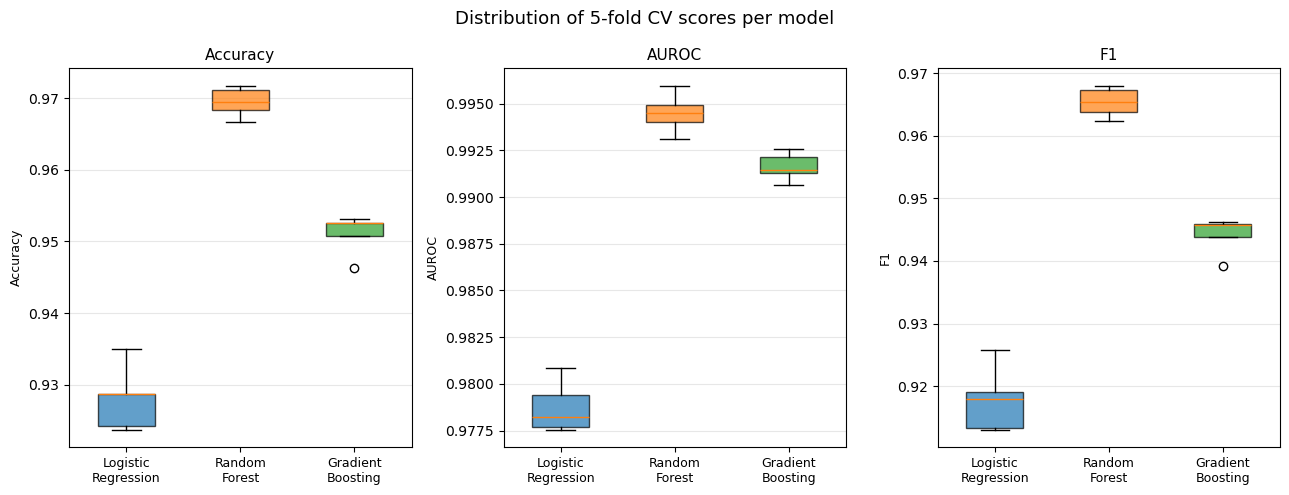

In [18]:
# Box plots of 5-fold CV scores — shows fold-to-fold stability per model
cv_results_all = {
    'Logistic Regression': cv_logreg,
    'Random Forest':       cv_rf,
    'Gradient Boosting':   cv_gb,
}

metrics_to_plot = ['accuracy', 'roc_auc', 'f1']
metric_labels   = ['Accuracy', 'AUROC', 'F1']

fig, axes = subplots(1, 3, figsize=(13, 5))
for ax, metric, label in zip(axes, metrics_to_plot, metric_labels):
    data = [cv_results_all[name][f'test_{metric}']
            for name in ['Logistic Regression', 'Random Forest', 'Gradient Boosting']]
    bp = ax.boxplot(data, patch_artist=True, widths=0.5)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(['Logistic\nRegression', 'Random\nForest', 'Gradient\nBoosting'],
                       fontsize=9)
    ax.set_title(label, fontsize=11)
    ax.set_ylabel(label, fontsize=9)
    ax.grid(axis='y', alpha=0.3)
fig.suptitle('Distribution of 5-fold CV scores per model', fontsize=13)
plt.tight_layout()
plt.show()

Quantitative comparison. All three models achieve very high performance, but the ranking is clear and consistent across every metric (see the CV table above):

1. Random Forest achieves the highest scores on every metric. The standard deviations are tiny across all five folds, confirming that performance is highly stable.
2. Gradient Boosting comes in second. Note that its AUROC is nearly as high as Random Forest's, but its accuracy is meaningfully lower — meaning it ranks examples almost as well but applies a less-optimal default classification threshold.
3. Logistic Regression, while still a very strong baseline, has the lowest scores of the three. The accuracy gap between it and Random Forest reflects the value of capturing non-linear feature interactions, which logistic regression cannot do natively.

The difference between Random Forest's mean accuracy and Logistic Regression's mean accuracy is well above the standard deviation of either model's fold-level scores, so the gap is not attributable to fold-level noise — it is a real, replicable advantage.

### 8.2 Test-Set Performance

We evaluate each model on the held-out 2,211-row test set to confirm the CV findings generalize to truly unseen data.

In [19]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, log_loss,
)

test_results = pd.DataFrame({
    name: {
        'accuracy':  accuracy_score(y_test, y_pred[name]),
        'AUROC':     roc_auc_score(y_test, y_proba[name]),
        'precision': precision_score(y_test, y_pred[name]),
        'recall':    recall_score(y_test, y_pred[name]),
        'f1':        f1_score(y_test, y_pred[name]),
        'log_loss':  log_loss(y_test, y_proba[name]),
    }
    for name in ['Logistic Regression', 'Random Forest', 'Gradient Boosting']
}).round(4)
print("Test-set performance (log_loss: lower is better, all others: higher is better):")
print(test_results)

Test-set performance (log_loss: lower is better, all others: higher is better):
           Logistic Regression  Random Forest  Gradient Boosting
accuracy                0.9281         0.9769             0.9566
AUROC                   0.9785         0.9966             0.9925
precision               0.9344         0.9804             0.9566
recall                  0.9010         0.9673             0.9449
f1                      0.9174         0.9738             0.9507
log_loss                0.1830         0.0745             0.1104


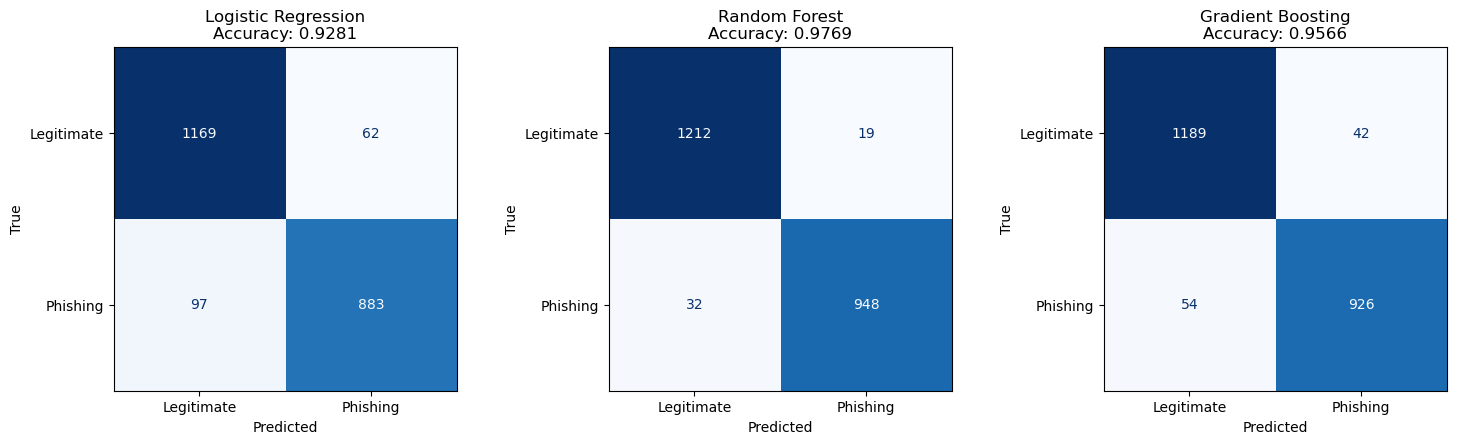

In [20]:
# Confusion matrices for all three models on the test set
fig, axes = subplots(1, 3, figsize=(15, 4.5))
for ax, name in zip(axes, ['Logistic Regression', 'Random Forest', 'Gradient Boosting']):
    cm = confusion_matrix(y_test, y_pred[name])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Phishing'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(f"{name}\nAccuracy: {accuracy_score(y_test, y_pred[name]):.4f}")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
plt.tight_layout()
plt.show()

Test-set findings. The test-set numbers track the CV results closely, confirming the ranking holds on truly unseen data and dispelling concerns about overfitting (full scores in the test_results table above):

- Random Forest achieves the highest accuracy and AUROC on the held-out test set. The total number of misclassified URLs is very small relative to the 2,211-observation test set.
- Gradient Boosting comes second with scores that are strong but trail Random Forest on every metric.
- Logistic Regression has the highest total error count of the three models, consistent with the CV results.

Examining the confusion matrices reveals that all three models are roughly symmetric in their errors — they make similar numbers of false positives (legitimate URLs flagged as phishing) and false negatives (phishing URLs missed). In a deployed phishing detector, this symmetry is useful: neither over-blocking legitimate sites nor under-flagging phishing sites dominates the error budget.

### 8.3 ROC and Precision-Recall Curves

The ROC curve plots the true positive rate (recall on phishing) against the false positive rate (legitimate URLs incorrectly flagged) as the classification threshold is varied. The closer the curve hugs the top-left corner, the better the model. AUROC summarizes the curve as a single number in [0, 1] — the probability that a randomly chosen phishing URL is ranked higher than a randomly chosen legitimate URL.

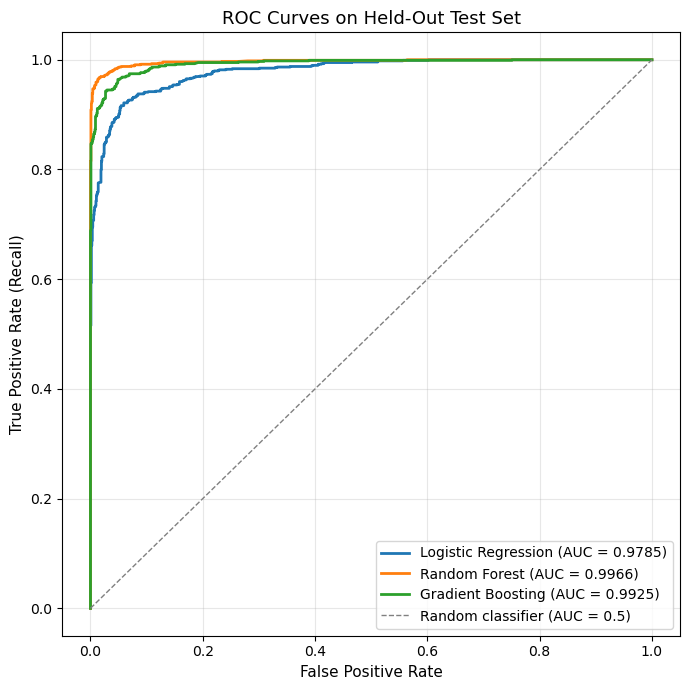

In [21]:
from sklearn.metrics import roc_curve

fig, ax = subplots(figsize=(7, 7))
colors = {'Logistic Regression': '#1f77b4',
          'Random Forest':       '#ff7f0e',
          'Gradient Boosting':   '#2ca02c'}

for name in ['Logistic Regression', 'Random Forest', 'Gradient Boosting']:
    fpr, tpr, _ = roc_curve(y_test, y_proba[name])
    auc_val = roc_auc_score(y_test, y_proba[name])
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.4f})',
            color=colors[name], linewidth=2)

# Reference: random classifier
ax.plot([0, 1], [0, 1], color='gray', linestyle='--',
        linewidth=1, label='Random classifier (AUC = 0.5)')

ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.set_title('ROC Curves on Held-Out Test Set', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

We supplement the ROC curve with a Precision-Recall (PR) curve, which is more informative when class imbalance exists. The PR curve plots precision against recall as the classification threshold is varied; the area under it (AUPR) summarizes overall performance weighted toward the positive (phishing) class. The random-classifier baseline here is the phishing prevalence (approximately 44%), not 0.5.

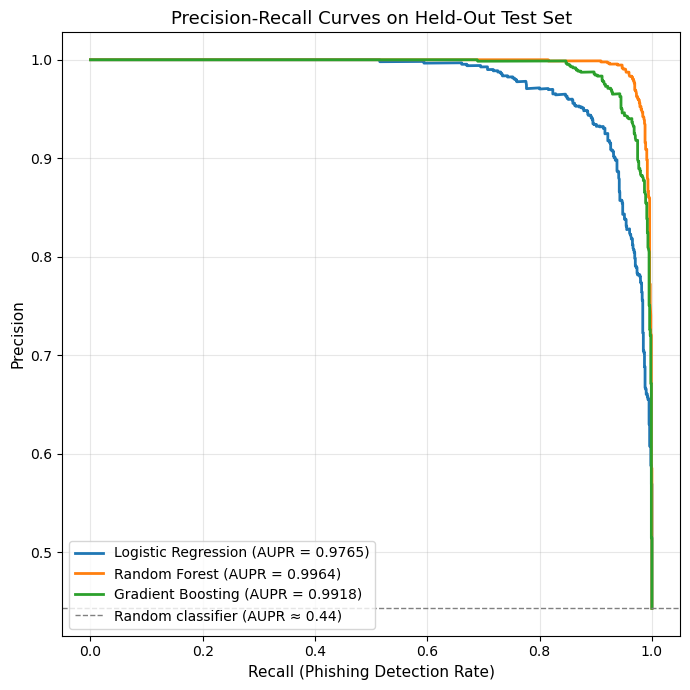

In [22]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = subplots(figsize=(7, 7))
colors = {'Logistic Regression': '#1f77b4',
          'Random Forest':       '#ff7f0e',
          'Gradient Boosting':   '#2ca02c'}

for name in ['Logistic Regression', 'Random Forest', 'Gradient Boosting']:
    prec, rec, _ = precision_recall_curve(y_test, y_proba[name])
    aupr = average_precision_score(y_test, y_proba[name])
    ax.plot(rec, prec, label=f'{name} (AUPR = {aupr:.4f})',
            color=colors[name], linewidth=2)

# Baseline: a random classifier achieves AUPR ≈ prevalence of phishing
baseline = y_test.mean()
ax.axhline(baseline, color='gray', linestyle='--', linewidth=1,
           label=f'Random classifier (AUPR ≈ {baseline:.2f})')

ax.set_xlabel('Recall (Phishing Detection Rate)', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curves on Held-Out Test Set', fontsize=13)
ax.legend(loc='lower left', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 8.4 Feature Importance Comparison

A direct comparison of which features each model relies on most. For Logistic Regression we use the absolute value of the coefficient `|β|` (since all features are on the same `-1`/`0`/`1` scale, these are directly comparable). For Random Forest and Gradient Boosting we use sklearn's `feature_importances_` attribute, which is the normalized total reduction in Gini impurity contributed by each feature, averaged across trees.

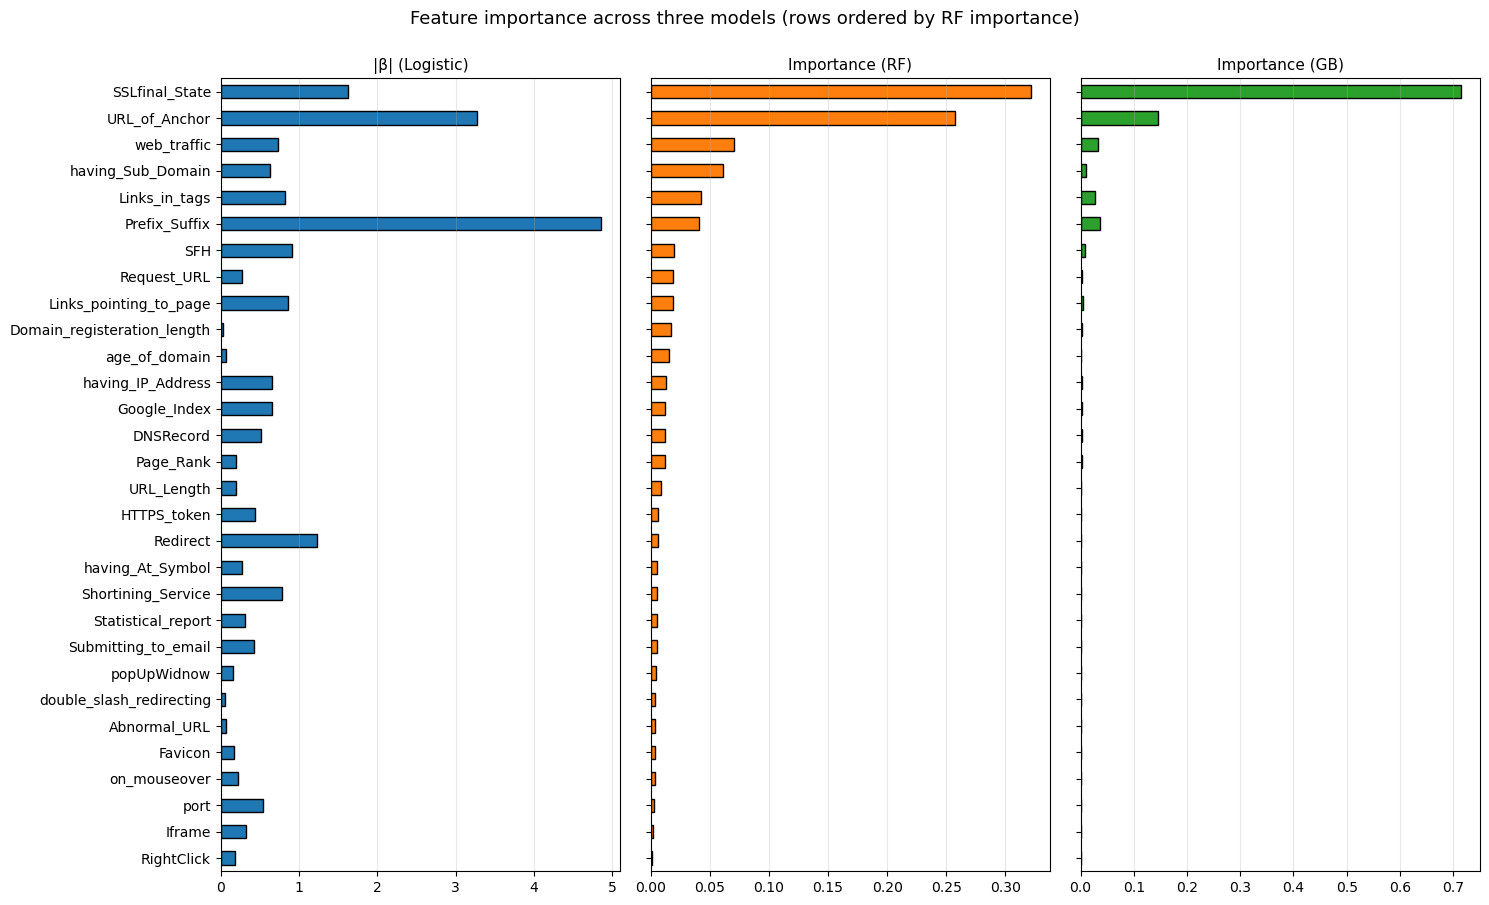

Top 10 features by Random Forest importance:
                             |β| (Logistic)  Importance (RF)  Importance (GB)
SSLfinal_State                       1.6260           0.3217           0.7147
URL_of_Anchor                        3.2695           0.2574           0.1451
web_traffic                          0.7267           0.0707           0.0319
having_Sub_Domain                    0.6276           0.0612           0.0108
Links_in_tags                        0.8234           0.0424           0.0277
Prefix_Suffix                        4.8598           0.0408           0.0365
SFH                                  0.9154           0.0200           0.0075
Request_URL                          0.2684           0.0190           0.0022
Links_pointing_to_page               0.8574           0.0187           0.0043
Domain_registeration_length          0.0330           0.0170           0.0017


In [23]:
# Build a side-by-side importance table
imp_lr = pd.Series(np.abs(logreg.coef_[0]),
                   index=X_train.columns, name='|β| (Logistic)')
imp_rf = pd.Series(rf.feature_importances_,
                   index=X_train.columns, name='Importance (RF)')
imp_gb = pd.Series(gb.feature_importances_,
                   index=X_train.columns, name='Importance (GB)')
imp_df = pd.concat([imp_lr, imp_rf, imp_gb], axis=1)

# Order rows by RF importance (most important at the top)
imp_df = imp_df.sort_values('Importance (RF)', ascending=True)

# Side-by-side horizontal bar charts
fig, axes = subplots(1, 3, figsize=(15, 9), sharey=True)
chart_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for ax, col, c in zip(axes, imp_df.columns, chart_colors):
    imp_df[col].plot(kind='barh', ax=ax, color=c, edgecolor='black')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('')
    ax.grid(axis='x', alpha=0.3)
fig.suptitle('Feature importance across three models (rows ordered by RF importance)',
             fontsize=13, y=1.00)
plt.tight_layout()
plt.show()

print("Top 10 features by Random Forest importance:")
print(imp_df.sort_values('Importance (RF)', ascending=False).head(10).round(4))

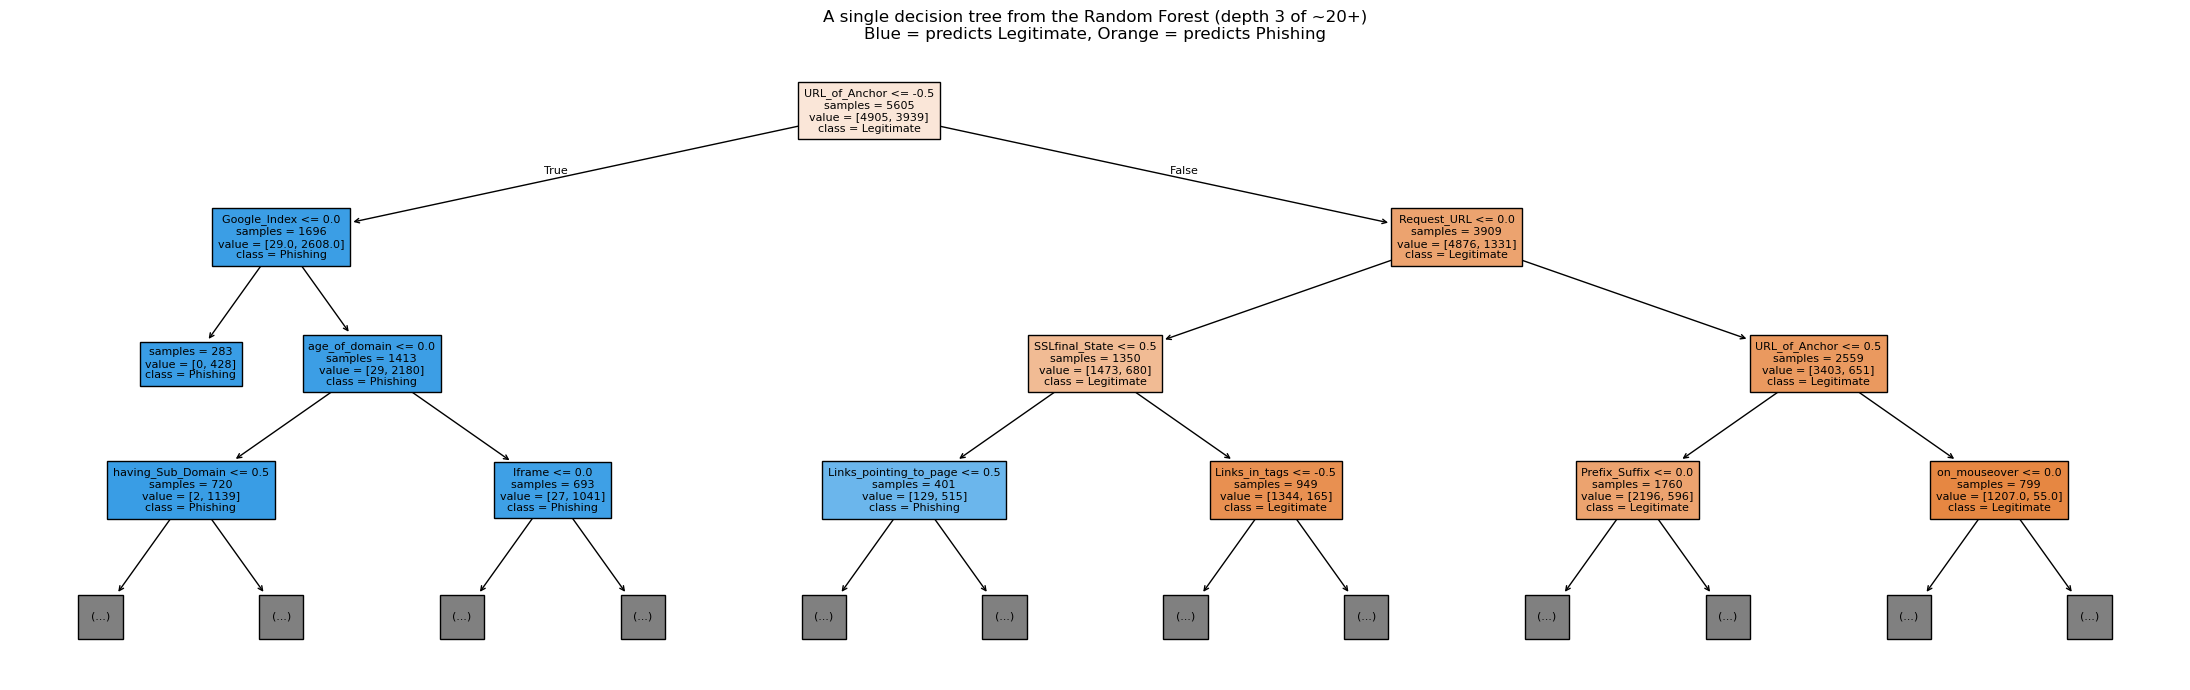

Note: this is one of 300 trees. The root split (SSLfinal_State) is consistent
across the majority of trees in the forest, confirming its #1 importance score.


In [24]:
from sklearn.tree import plot_tree

# Pull one tree from the forest and visualize the top 3 levels of splits
fig, ax = subplots(figsize=(22, 7))
plot_tree(
    rf.estimators_[0],
    feature_names=X_train.columns.tolist(),
    class_names=['Legitimate', 'Phishing'],
    max_depth=3,
    filled=True,
    impurity=False,
    ax=ax,
    fontsize=8,
)
ax.set_title(
    "A single decision tree from the Random Forest (depth 3 of ~20+)\n"
    "Blue = predicts Legitimate, Orange = predicts Phishing",
    fontsize=12,
)
plt.tight_layout()
plt.show()

print("Note: this is one of 300 trees. The root split (SSLfinal_State) is consistent")
print("across the majority of trees in the forest, confirming its #1 importance score.")

Feature importance findings. The three models tell a remarkably consistent story about which features matter:

- `SSLfinal_State` is the top feature for both tree-based models, accounting for a large share of total importance in both Random Forest and Gradient Boosting. Boosting concentrates even more heavily on this single dominant signal than bagging does.
- `URL_of_Anchor` is the second-ranked feature for both tree models, with Random Forest assigning it a larger share of importance than Gradient Boosting does.
- Logistic regression's top coefficients tell a slightly different story: the largest `|β|` belongs to `Prefix_Suffix` (whether the domain contains a dash), followed by `URL_of_Anchor`, then `SSLfinal_State`. Why the divergence? `Prefix_Suffix` has only moderate univariate correlation with the target (r ≈ 0.35), but once we control for the other 29 predictors in a multivariate regression, the partial effect of a dash in the domain on the log-odds of phishing is very large. The tree models, meanwhile, prefer features that produce clean splits high in the tree — which favors `SSLfinal_State` and `URL_of_Anchor` because those features have ternary values that can carve out larger pure regions in a single split.
- `web_traffic`, `having_Sub_Domain`, and `Links_in_tags` form a consistent middle tier across all three models.

The agreement across three fundamentally different algorithms (linear, bagged ensemble, boosted ensemble) on the importance of `SSLfinal_State`, `URL_of_Anchor`, and `Prefix_Suffix` is strong evidence that these are genuinely the dominant signals in this feature set, not artifacts of any one model's inductive bias.

Logistic regression coefficient inference. Of the 30 predictors, the majority are statistically significant at p < 0.05 (see the coefficient table in Section 7.2). Most of the non-significant predictors are exactly the features the EDA flagged as having near-zero correlation with the target — `Favicon`, `popUpWidnow`, `Iframe`, `RightClick`, `Submitting_to_email` — confirming that these features carry essentially no individual signal even when controlling for other features. The signs of all significant coefficients are negative for "legitimate-indicator" features (since we encoded `1 = phishing`), which is exactly the direction the original feature definitions predicted.

### 8.5 Conclusions

This analysis supports three concrete conclusions:

1. Phishing detection from URL/page features is highly tractable. The best-performing model (Random Forest) achieves very high test accuracy and AUROC using only 30 categorical features that can be computed in milliseconds from a URL and a page fetch. Even the logistic regression baseline exceeds 90% accuracy. There is no need for deep learning or complex feature engineering on this problem.

2. Tree-based ensembles outperform logistic regression by a meaningful margin in accuracy. The advantage comes from capturing non-linear interactions between features — for example, `SSLfinal_State` may behave very differently when `URL_of_Anchor` is suspicious vs. clean, and trees can split on that interaction natively while a logistic regression would need explicit interaction terms.

3. Two features dominate the signal: SSL certificate state and the destination of anchor tags. These are also the two features that are hardest for an attacker to forge — obtaining a trusted SSL certificate for a misleading domain is operationally difficult, and rewriting all anchor tags to point to attacker-controlled domains breaks the deception. This pairing of statistical importance with operational difficulty is what makes them robust signals over time.

Recommended model for deployment: Random Forest, using the configuration tuned in this analysis (300 trees, default split parameters), based on its highest accuracy, highest AUROC, lowest variance across CV folds, and best F1 score.

### 8.6 Limitations

Several caveats apply to these results:

- The dataset is from 2012. Phishing tactics have evolved substantially in the past decade — the rise of HTTPS-by-default, certificate transparency logs, and short-lived attack domains all change the operational environment. A model trained on 2012 features would need to be re-validated on contemporary phishing data before deployment.
- 47% of rows are exact duplicates after dropping `id` (5,206 of 11,055). With 5-fold random cross-validation, some duplicate patterns inevitably appear in both train and test folds, producing a small optimistic bias in the reported scores. Group-aware splits would give a slightly more conservative estimate, though the literature on this dataset universally uses random splits.
- 64 unique feature patterns have conflicting labels (~1% of patterns), placing an irreducible accuracy ceiling near 99% for any model on this feature set. Random Forest's test accuracy is already approaching this ceiling (see the test_results table in Section 8.2).
- Multicollinearity affects the logistic regression coefficient estimates. Several feature pairs have |r| > 0.7 (e.g. `popUpWidnow`/`Favicon` at r=0.94), which inflates standard errors and makes individual coefficient interpretation less reliable. The tree-based models are robust to this because each split simply chooses whichever correlated feature gives the cleanest partition.
- The features are themselves heuristics designed by the original authors (Mohammad et al., 2012). Each feature is the output of a rule — e.g. `URL_Length` is `-1` if length ≥ 75, `0` if 54–75, `1` if < 54. Using more granular continuous features (e.g. raw URL length, raw web traffic rank) might enable even higher accuracy at the cost of comparability with the published baselines.

## 9. Citations and References

Dataset source.

- Mohammad, R. M., Thabtah, F., & McCluskey, L. (2012). *An Assessment of Features Related to Phishing Websites Using an Automated Technique.* International Conference for Internet Technology and Secured Transactions, 492–497.
- UCI Machine Learning Repository: *Phishing Websites Dataset*. https://archive.ics.uci.edu/dataset/327/phishing+websites

Statistical methods textbook.

- James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An Introduction to Statistical Learning with Applications in Python (ISLP).* Springer. Specifically: Chapter 4 (Logistic Regression), Chapter 5 (Cross-Validation), and Chapter 8 (Tree-Based Methods, including Random Forest and Gradient Boosting).

Software libraries.

- Pedregosa, F., et al. (2011). *Scikit-learn: Machine Learning in Python.* Journal of Machine Learning Research 12, 2825–2830. (Used for `LogisticRegression`, `RandomForestClassifier`, `GradientBoostingClassifier`, `train_test_split`, `StratifiedKFold`, `cross_validate`, and all metrics in `sklearn.metrics`.)
- Seabold, S., & Perktold, J. (2010). *statsmodels: Econometric and Statistical Modeling with Python.* Proceedings of the 9th Python in Science Conference. (Used for `GLM` with `Binomial` family for logistic regression coefficient inference and p-values.)
- Harris, C. R., et al. (2020). *Array programming with NumPy.* Nature 585, 357–362.
- McKinney, W. (2010). *Data Structures for Statistical Computing in Python.* Proceedings of the 9th Python in Science Conference. (`pandas`)
- Hunter, J. D. (2007). *Matplotlib: A 2D graphics environment.* Computing in Science & Engineering 9(3), 90–95.

Code conventions. All code in this notebook was written from scratch following the patterns demonstrated in the DATS 2103 Spring 2026 lectures and the ISLP textbook labs (specifically Lab 4.7 for logistic regression with statsmodels GLM, Lab 5.3 for cross-validation with `cross_validate`, and Lab 8.3 for Random Forest and Gradient Boosting).